
# 05 — Leverage logistic regression classification models

In this notebook, you'll build a binary classification model using **logistic regression** with the UCLA Admissions dataset.

The goal is to predict whether a student was admitted based on their **GPA**, **GRE**, and **academic rank**.


## Import libraries

In [47]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load the UCLA Admissions dataset

In [48]:
import pandas as pd
data = pd.read_csv('https://stats.idre.ucla.edu/stat/data/binary.csv')
print(data)


     admit  gre   gpa  rank
0        0  380  3.61     3
1        1  660  3.67     3
2        1  800  4.00     1
3        1  640  3.19     4
4        0  520  2.93     4
..     ...  ...   ...   ...
395      0  620  4.00     2
396      0  560  3.04     3
397      0  460  2.63     2
398      0  700  3.65     2
399      0  600  3.89     3

[400 rows x 4 columns]


## Define features (X) and target (y)

In [49]:
from sklearn.model_selection import train_test_split

X = data[["gre", "gpa", "rank"]]
y = data[["admit"]]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape


((280, 3), (120, 3))

## Create and fit the logistic regression model

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

## Make sample predictions

In [51]:
predictions = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

pd.DataFrame({
    'GRE': X_test['gre'],
    'GPA': X_test['gpa'],
    'Academic Rank': X_test['rank'],
    'Admit': y_test['admit'],
    'Predictions': predictions,
    'Propbability': probs.round(3)
})

,GRE,GPA,Academic Rank,Admit,Predictions,Propbability
209,580,3.50,2,0,0,0.370
280,660,3.94,2,0,0,0.485
33,800,4.00,3,1,0,0.429
210,740,3.34,4,0,0,0.198
93,580,2.93,2,0,0,0.275
...,...,...,...,...,...,...
60,620,3.18,2,1,0,0.330
79,620,4.00,1,1,1,0.605
285,600,3.31,4,0,0,0.160
305,580,3.46,4,0,0,0.171


In [52]:
import sklearn.metrics as metrics

accuracy = metrics.accuracy_score(y_test, predictions)
print(f"Accuracy = {accuracy}")

Accuracy = 0.725


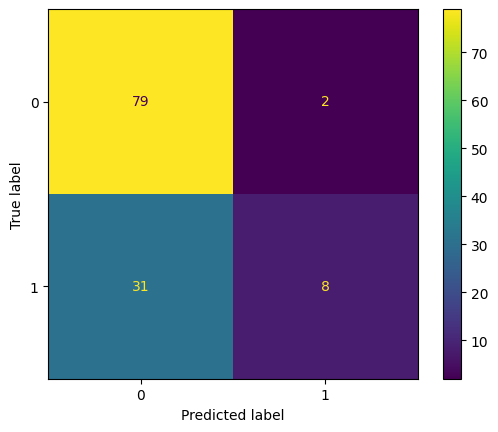

In [56]:
cm = metrics.confusion_matrix(y_test, predictions)
diagram = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
diagram.plot(values_format='d')

In [58]:
# TP + TN / ALL
accuracy = metrics.accuracy_score(y_test, predictions)

# TP / TP + FP
precision = metrics.precision_score(y_test, predictions, pos_label=0)

# TP / TP + FN
recall = metrics.recall_score(y_test, predictions)

# 2 x ((Precision x Recall) / Precision + Recall)
f1 = metrics.f1_score(y_test, predictions)

print(f"Precision = {precision}")
print(f"Accuracy = {accuracy}")
print(f"F1 = {f1:.3f}")
print(f"recall = {recall:.3f}")


Precision = 0.7181818181818181
Accuracy = 0.725
F1 = 0.327
recall = 0.205
